# AWG5208 + ATS9371: 500 ns Gaussian-square × 50 MHz

接線：

- AWG CH3 analog output → ATS9371 Channel A
- AWG CH1 Marker 1 → ATS9371 TRIG IN
- 確認兩端皆使用正確的 50 Ω termination

流程：先 arm Alazar，再啟動 AWG；每個 5 µs waveform loop 產生一次 marker trigger。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from awg5200 import AWG5208, gaussian_square_ns, waveform, delay, triangle_ns
from alazar import (
    ATSApi,
    AcquisitionConfig,
    TriggerConfig,
    abort_capture,
    adc_codes_to_volts,
    arm_capture,
    average_shots,
    configure_ats9371,
    correct_interleaving_offsets,
    digital_downconvert,
    dispersive_demodulate_seconds,
    emission_demodulate,
    free_capture,
    moving_average_time_axis,
    open_ats9371,
    recover_clock_referenced_envelope,
    start_capture,
    wait_for_capture,
)
from alazar.constants import CHANNEL_B

plt.rcParams['figure.figsize'] = (9, 4.5)


## Experiment parameters

`NUM_AVERAGES` 必須能被 `RECORDS_PER_BUFFER` 整除。為方便測試，下面會自動選擇可整除的 buffer 大小。

In [2]:
AWG_RESOURCE = 'TCPIP0::192.168.10.171::inst0::INSTR'

AWG_SAMPLE_RATE_HZ = 2.5e9
AWG_TOTAL_DURATION_S = 5e-6
READOUT_START_DELAY_S = 1e-6
PULSE_DURATION_NS = 500
EDGE_SIGMA_NS = 10
CARRIER_FREQUENCY_HZ = 50e6
PULSE_PEAK_VOLTS = 0.2
CHANNEL_AMPLITUDE_VPP = 0.5

AWG_SIGNAL_CHANNEL = 3
AWG_MARKER_CHANNEL = 1
MARKER_LOW_VOLTS = 0.0
MARKER_HIGH_VOLTS = 1.2
MARKER_ADVANCE_NS = 200

ALAZAR_SAMPLE_RATE_HZ = 1e9
ALAZAR_SAMPLES_PER_RECORD = 2560  # 2.56 us at 1 GS/s
ALAZAR_TRIGGER_LEVEL = 140
ALAZAR_TIMEOUT_MS = 10_000
ALAZAR_INPUT_RANGE_VOLTS = 0.4

NUM_AVERAGES = 1000
MOVING_AVERAGE_SAMPLES = 20
BASELINE_STOP_S = 100e-9
INTEGRATION_DELAY_S = 200e-9
INTEGRATION_TIME_S = 500e-9


## Connect and configure AWG

CH3 播放 500 ns Gaussian-square × 50 MHz。CH1 analog waveform 為 0 V，Marker 1 自動包住 CH3 pulse。

In [3]:
awg = AWG5208.connect(AWG_RESOURCE, timeout_ms=60_000)
print('AWG:', awg.identify())

awg.set_awg_mode()
awg.use_external_10mhz_reference()
awg.set_sample_rate(AWG_SAMPLE_RATE_HZ)

# readout_envelope = gaussian_square_ns(
#     duration_ns=1000,
#     sample_rate_hz=AWG_SAMPLE_RATE_HZ,
#     edge_sigma_ns=100,
#     amplitude_volts=PULSE_PEAK_VOLTS,
# )


readout_envelope = triangle_ns(
    duration_ns=PULSE_DURATION_NS,
    sample_rate_hz=AWG_SAMPLE_RATE_HZ,
    frequency_hz=CARRIER_FREQUENCY_HZ,
    half_width_ns=100,
    amplitude_volts=PULSE_PEAK_VOLTS,
)


readout = waveform(
    readout_envelope,
    fc=CARRIER_FREQUENCY_HZ,
    ch=AWG_SIGNAL_CHANNEL,
    name='readout_500ns_50MHz',
)
timeline = delay(READOUT_START_DELAY_S) / readout
names = awg.upload_timeline(
    timeline,
    amplitude_vpp={AWG_SIGNAL_CHANNEL: CHANNEL_AMPLITUDE_VPP},
    total_duration_s=AWG_TOTAL_DURATION_S,
)

marker_name = awg.marker(
    waveform_ch=AWG_SIGNAL_CHANNEL,
    marker_ch=AWG_MARKER_CHANNEL,
    marker_number=1,
    low_volts=MARKER_LOW_VOLTS,
    high_volts=MARKER_HIGH_VOLTS,
    padding_samples=round(MARKER_ADVANCE_NS * 1e-9 * AWG_SAMPLE_RATE_HZ),
    amplitude_vpp=CHANNEL_AMPLITUDE_VPP,
)

print('Signal waveform:', names[AWG_SIGNAL_CHANNEL])
print('Marker waveform:', marker_name)
print('AWG error:', awg.query('SYSTem:ERRor?'))


AWG: TEKTRONIX,AWG5208,B030598,FV:6.6.0131.0
Signal waveform: readout_500ns_50MHz
Marker waveform: marker_ch1_for_ch3
AWG error: 0,"No error"


## Connect and configure ATS9371

In [4]:
ats_api = ATSApi()
ats_board = open_ats9371(ats_api)

configure_ats9371(
    ats_api,
    ats_board,
    TriggerConfig(
        level=ALAZAR_TRIGGER_LEVEL,
        delay_samples=0,
        timeout_ticks=0,
    ),
    use_external_10mhz_reference=True,
)

print('ATS9371 bits/sample:', ats_board.bits_per_sample)
print('ATS9371 memory samples:', ats_board.memory_samples)


ATS9371 bits/sample: 12
ATS9371 memory samples: 4294967294


## Acquisition function

`run_experiment(num_averages)` 會先停止 AWG、arm ATS9371，再啟動 AWG。無論成功或失敗，都會停止 AWG 並釋放 DMA memory。

In [5]:
def records_per_buffer_for(num_averages, maximum=100):
    for candidate in range(min(maximum, num_averages), 0, -1):
        if num_averages % candidate == 0:
            return candidate
    raise RuntimeError('No records_per_buffer divisor found')


def run_experiment(num_averages):
    if num_averages < 1:
        raise ValueError('num_averages must be positive')

    records_per_buffer = records_per_buffer_for(num_averages)
    acquisition = AcquisitionConfig(
        sample_rate_hz=ALAZAR_SAMPLE_RATE_HZ,
        tone_frequency_hz=CARRIER_FREQUENCY_HZ,
        samples_per_record=ALAZAR_SAMPLES_PER_RECORD,
        num_averages=num_averages,
        records_per_buffer=records_per_buffer,
        dma_buffer_count=4,
        input_range_volts=ALAZAR_INPUT_RANGE_VOLTS,
        timeout_ms=ALAZAR_TIMEOUT_MS,
        channel=CHANNEL_B,
    )

    awg.stop()
    session = arm_capture(ats_api, ats_board, acquisition)
    try:
        start_capture(ats_api, session)
        print(
            f'ATS armed: {num_averages} records, '
            f'{records_per_buffer} records/buffer'
        )
        awg.run(wait_until_ready=False)
        raw_codes = wait_for_capture(
            ats_api,
            session,
            acquisition.timeout_ms,
        )
    finally:
        awg.stop()
        abort_capture(ats_api, session)
        free_capture(session)

    records_volts = adc_codes_to_volts(
        raw_codes,
        ats_board.bits_per_sample,
        acquisition.input_range_volts,
    )
    return acquisition, raw_codes, records_volts


## Run acquisition

In [6]:
NUM_AVERAGES = 100
acquisition, raw_codes, records_volts = run_experiment(NUM_AVERAGES)

print('Raw shape:', raw_codes.shape)
print('Voltage shape:', records_volts.shape)
print('AWG state after capture:', awg.run_state())
print('AWG error:', awg.query('SYSTem:ERRor?'))


ATS armed: 100 records, 100 records/buffer
Raw shape: (100, 2560)
Voltage shape: (100, 2560)
AWG state after capture: 0
AWG error: 0,"No error"


## Raw data plot

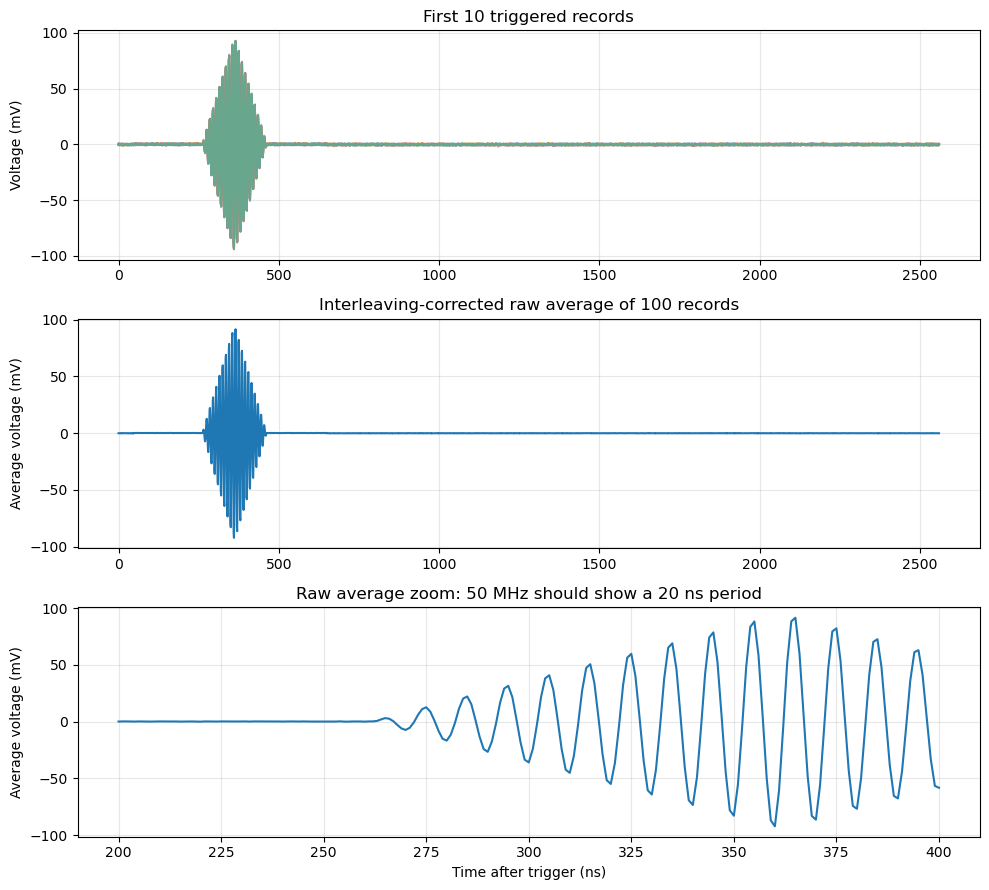

In [7]:
raw_time_ns = (
    np.arange(acquisition.samples_per_record)
    / acquisition.sample_rate_hz
    * 1e9
)
baseline_stop_sample = round(BASELINE_STOP_S * acquisition.sample_rate_hz)
records_for_plot = correct_interleaving_offsets(
    records_volts,
    baseline_stop_sample,
)

fig, axes = plt.subplots(3, 1, figsize=(10, 9))

number_to_plot = min(10, records_for_plot.shape[0])
for record in records_for_plot[:number_to_plot]:
    axes[0].plot(raw_time_ns, record * 1e3, alpha=0.45)
axes[0].set_ylabel('Voltage (mV)')
axes[0].set_title(f'First {number_to_plot} triggered records')
axes[0].grid(True, alpha=0.3)

average_raw = records_for_plot.mean(axis=0)
axes[1].plot(raw_time_ns, average_raw * 1e3)
axes[1].set_ylabel('Average voltage (mV)')
axes[1].set_title(
    f'Interleaving-corrected raw average of {records_for_plot.shape[0]} records'
)
axes[1].grid(True, alpha=0.3)

zoom_start_ns = MARKER_ADVANCE_NS
zoom_stop_ns = MARKER_ADVANCE_NS + 200
zoom_mask = (raw_time_ns >= zoom_start_ns) & (raw_time_ns <= zoom_stop_ns)
axes[2].plot(raw_time_ns[zoom_mask], average_raw[zoom_mask] * 1e3)
axes[2].set_xlabel('Time after trigger (ns)')
axes[2].set_ylabel('Average voltage (mV)')
axes[2].set_title('Raw average zoom: 50 MHz should show a 20 ns period')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Time-resolved demodulation plot

先將 50 MHz 混到 complex baseband，再使用 moving average 低通。

ValueError: x and y must have same first dimension, but have shapes (2541,) and (2560,)

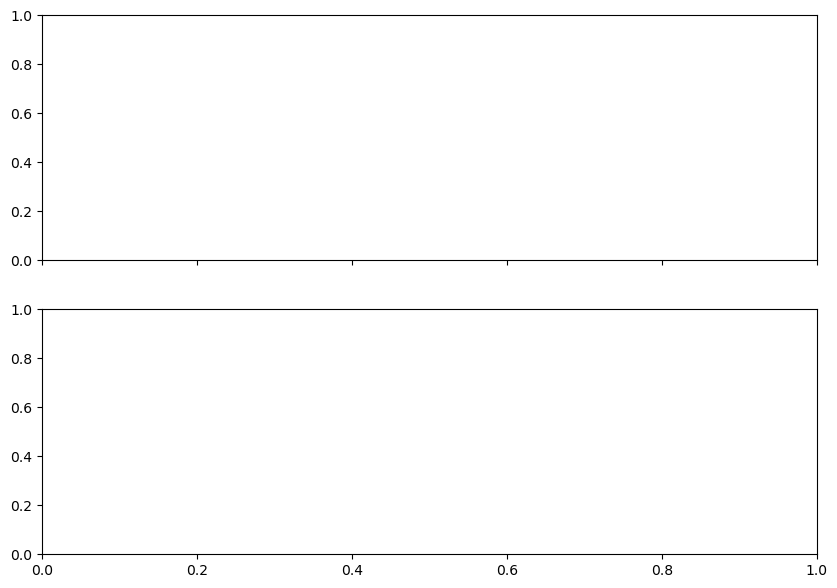

In [ ]:
baseline_stop_sample = round(BASELINE_STOP_S * acquisition.sample_rate_hz)
emission_iq, emission_iq_average, rms_envelope = recover_clock_referenced_envelope(
    records_volts,
    acquisition.sample_rate_hz,
    CARRIER_FREQUENCY_HZ,
    baseline_stop_sample=baseline_stop_sample,
    window_samples=MOVING_AVERAGE_SAMPLES,
)
demod_time_ns = moving_average_time_axis(
    acquisition.samples_per_record,
    acquisition.sample_rate_hz,
    MOVING_AVERAGE_SAMPLES,
) * 1e9

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
axes[0].plot(demod_time_ns, emission_iq_average.real * 1e3, label='I')
axes[0].plot(demod_time_ns, emission_iq_average.imag * 1e3, label='Q')
axes[0].set_ylabel('IQ voltage (mV)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    demod_time_ns,
    np.abs(emission_iq_average) * 1e3,
    label='|mean(IQ)|',
)
axes[1].plot(
    demod_time_ns,
    rms_envelope * 1e3,
    '--',
    label='RMS(|IQ|), includes noise floor',
)
axes[1].set_xlabel('Time after trigger (ns)')
axes[1].set_ylabel('|IQ| (mV)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Integrated IQ plot

每個 trigger record 積分成一個 complex IQ point。

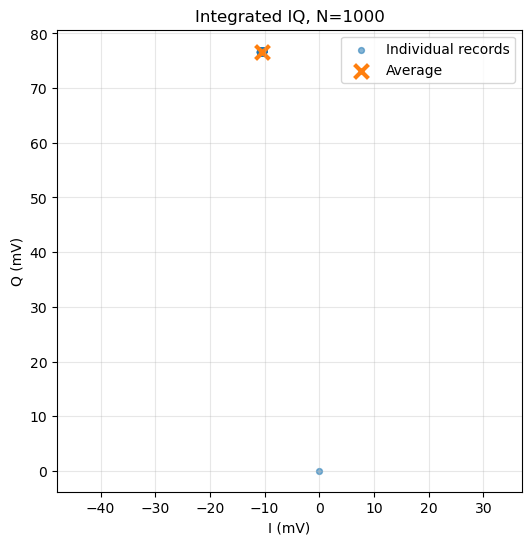

Average IQ: (-0.010510020844819128+0.07664604022751013j)
Average amplitude (mV): 77.36327307395696
Average phase (rad): 1.7070705655541487


In [16]:
integrated_iq = dispersive_demodulate_seconds(
    records_for_plot,
    acquisition.sample_rate_hz,
    CARRIER_FREQUENCY_HZ,
    integration_delay_s=INTEGRATION_DELAY_S,
    integration_time_s=INTEGRATION_TIME_S,
)
integrated_iq_average = average_shots(integrated_iq)

plt.figure(figsize=(6, 6))
plt.scatter(
    integrated_iq.real * 1e3,
    integrated_iq.imag * 1e3,
    s=18,
    alpha=0.55,
    label='Individual records',
)
plt.scatter(
    [integrated_iq_average.real * 1e3],
    [integrated_iq_average.imag * 1e3],
    s=100,
    marker='x',
    linewidths=3,
    label='Average',
)
plt.xlabel('I (mV)')
plt.ylabel('Q (mV)')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.legend()
plt.title(f'Integrated IQ, N={len(integrated_iq)}')
plt.show()

print('Average IQ:', integrated_iq_average)
print('Average amplitude (mV):', abs(integrated_iq_average) * 1e3)
print('Average phase (rad):', np.angle(integrated_iq_average))


## Optional save and close

In [ ]:
np.savez(
    'awg_alazar_50mhz_capture.npz',
    raw_codes=raw_codes,
    records_volts=records_volts,
    emission_iq=emission_iq,
    emission_iq_average=emission_iq_average,
    integrated_iq=integrated_iq,
    integrated_iq_average=integrated_iq_average,
    awg_sample_rate_hz=AWG_SAMPLE_RATE_HZ,
    alazar_sample_rate_hz=ALAZAR_SAMPLE_RATE_HZ,
    carrier_frequency_hz=CARRIER_FREQUENCY_HZ,
)

awg.stop()
awg.close()
print('Saved awg_alazar_50mhz_capture.npz and closed AWG connection.')


Saved awg_alazar_50mhz_capture.npz and closed AWG connection.
